In [3]:
import numpy as np  
import matplotlib.pyplot as plt 
import random
from random import sample
import scipy
import emcee


<ErrorbarContainer object of 3 artists>

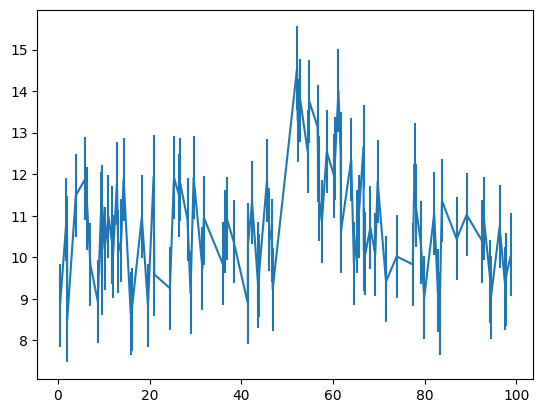

In [ ]:
data=np.load("Transient.npy")
time=data[:,0]
flux=data[:,1]
err=data[:,2]
plt.errorbar(time, flux,yerr=err)

In [22]:
def pdf (t,b,A,t0,alpha):
    if t<t0:
        return b
    else:   
        return b + A*np.exp(-(t-t0)/alpha)
    
def Likelihood(x,b,A,t0,alpha):
    return np.prod(pdf(x,b,A,t0,alpha))

def prior(x): #the costant prior are not important 
    return 1/x 

def Posterior (x,b,A,t0,alpha):
    return Likelihood(x,b,A,t0,alpha) * prior(x)

def LogPosterior(b,A,t0,alpha,x):
    return np.log(Posterior(x,b,A,t0,alpha))

In [31]:
ndim = 4  # number of parameters in the model
nwalkers = 6  # number of MCMC walkers
burn = 10000  # "burn-in" period to let chains stabilize
nsteps = 100000  # number of MCMC steps to take **for each walker**

# initialize theta 
np.random.seed(0)
starting_guesses = np.random.random((nwalkers, ndim)) #starting point for each walker

# the function call where all the work happens: 
sampler = emcee.EnsembleSampler(nwalkers, ndim, LogPosterior, args=[flux])
sampler
#sampler.run_mcmc(starting_guesses, nsteps)

#emcee_trace  = sampler.chain[:, burn:, :].reshape(-1, ndim)

